In [1]:
!pip install stanza


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.9/586.9 kB 10.8 MB/s eta 0:00:00


In [2]:
# Gerekli kütüphaneler
import re  # Metin temizleme ve düzenli ifadeler için
import pandas as pd  # Veri tabanı işleme için
import matplotlib.pyplot as plt  # Görselleştirme için
import ipywidgets as widgets  # Interaktif bileşenler için
from IPython.display import display, clear_output  # Veri Setini Yükleme
import stanza  # Türkçe için Stanza kütüphanesi
import sys
import difflib

# Çevre kontrolü: Google Colab mi yoksa yerel (VS Code vb.) mi?
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import files


In [3]:
# Stanza'yı indirip başlatıyoruz
stanza.download('tr')  # Türkçe modelini indiriyoruz
# Hız ve bellek optimizasyonu için sadece gerekli işlemcileri başlatıyoruz
nlp = stanza.Pipeline('tr', processors='tokenize,mwt,pos,lemma')


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: tr (Turkish) ...


INFO:stanza:Downloaded file to /root/stanza_resources/tr/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: tr (Turkish):
| Processor | Package       |
-----------------------------
| tokenize  | imst          |
| mwt       | imst          |
| pos       | imst_charlm   |
| lemma     | imst_nocharlm |
| depparse  | imst_charlm   |
| ner       | starlang      |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!


In [15]:
# Veri Setini Yükleme
if IN_COLAB:
    print("Google Colab ortamı algılandı. Lütfen 'Yemek_Veri_Tabanı.csv' dosyasını yükleyin:")
    uploaded = files.upload()
else:
    print("Yerel ortam algılandı. 'Yemek_Veri_Tabanı.csv' doğrudan proje dizininden yüklenecektir.")


Saving Yemek_Veri_Tabanı.csv to Yemek_Veri_Tabanı (1).csv


In [17]:
# CSV dosyasını yükleyin ve malzeme isimlerini lemmatize edin
df = pd.read_csv('Yemek_Veri_Tabanı.csv')

print("Veri tabanı yüklendi. Malzeme adları lemmatize ediliyor (bu işlem birkaç saniye sürebilir)...")
lemmatized_names = []
for name in df['Malzeme Adı']:
    doc = nlp(str(name).lower())
    lemmas = []
    for sent in doc.sentences:
        for word in sent.words:
            lemma = word.lemma if word.lemma else word.text
            lemmas.append(lemma)
    lemmatized_names.append(" ".join(lemmas))
df['Lemmatized_Adı'] = lemmatized_names
print("Veri tabanı eşleştirmeye hazır.")

# İlk 5 satırı inceleyin
df.head()


,Malzeme Adı,Porsiyon (g),Enerji (kcal),Yağ (g),Karbonhidrat (g),Protein (g),Şeker (g),Fiber (g)
0,Acur,100,23,0.18,5.16,0.72,4.62,0.8
1,Ahududu,100,52,0.65,11.94,1.20,4.42,6.5
2,Alabalık,100,138,5.40,0.00,20.87,0.00,0.0
3,Ananas,100,48,0.12,12.63,0.54,9.26,1.4
4,Andız Pekmezi,100,276,0.00,68.50,1.25,32.00,0.0


In [18]:
# Sütun adlarını kontrol edin
df.columns


Index(['Malzeme Adı', 'Porsiyon (g)', 'Enerji (kcal)', 'Yağ (g)',
       'Karbonhidrat (g)', 'Protein (g)', 'Şeker (g)', 'Fiber (g)'],
      dtype='object')

In [19]:
# Ölçü birimleri ve gram karşılıkları
olcu_birimleri = {
    "gram": 1,
    "gr": 1,
    "kg": 1000,
    "kilo": 1000,  # 1 kilo = 1000 gram olarak düzeltildi
    "kilogram": 1000,
    "litre": 1000,
    "li": 1000,
    "mililitre": 1,
    "ml": 1,
    "yemek kaşığı": 15,
    "tatlı kaşığı": 10,
    "çay kaşığı": 5,
    "su bardağı": 200,
    "çay bardağı": 100,
    "dilim": 30,
    "adet": 100,
    "tane": 100
}


In [20]:
# Lemmatizasyon işlemi için Stanza
def lemmatize_text(text):
    doc = nlp(text)  # Metni Stanza ile analiz et
    lemmatized_words = []
    for sent in doc.sentences:
        for word in sent.words:
            lemma = word.lemma if word.lemma else word.text
            lemmatized_words.append(lemma)  # Lemma (kök) halini al
    return " ".join(lemmatized_words)  # Lemmatize edilmiş metni döndür


In [21]:
INVALID_POS = {'CCONJ', 'VERB', 'AUX', 'PRON', 'PUNCT', 'NUM', 'ADP', 'SCONJ'}
RECIPE_STOP_WORDS = {
    've', 'veya', 'kullan', 'kullanmak', 'ekle', 'eklemek', 'yap', 'yapmak', 
    'karıştır', 'karıştırmak', 'koy', 'koymak', 'al', 'almak', 'tüket', 'tüketmek', 
    'iste', 'istemek', 'doğra', 'doğramak'
}

def malzeme_ve_miktar_bul(metin):
    """
    Tarif metninden malzemeleri ve miktarları Stanza POS etiketleyici ile ayıklar.
    İki kelimelik ölçü birimlerini (örn. yemek kaşığı) destekler.
    """
    doc = nlp(metin)
    words = []
    for sent in doc.sentences:
        words.extend(sent.words)
    
    malzemeler = []
    i = 0
    n = len(words)
    
    while i < n:
        word = words[i]
        # Kelime sayı ise (NUM veya rakam ise)
        if word.upos == 'NUM' or word.text.isdigit():
            # Sonraki kelime bir ölçü birimi mi? (1 veya 2 kelimeli birim kontrolü)
            matched_unit = None
            j_start = i + 1
            
            # Önce 2 kelimelik birimleri kontrol et (örn: yemek kaşığı)
            if i + 2 < n:
                w1 = words[i+1]
                w2 = words[i+2]
                two_word_candidate = f"{w1.text.lower()} {w2.text.lower()}"
                if two_word_candidate in olcu_birimleri:
                    matched_unit = two_word_candidate
                    j_start = i + 3
            
            # Eğer 2 kelimelik eşleşmediyse 1 kelimeliği kontrol et
            if not matched_unit and i + 1 < n:
                w1 = words[i+1]
                unit_candidate = w1.text.lower()
                unit_lemma = w1.lemma.lower() if w1.lemma else unit_candidate
                if unit_candidate in olcu_birimleri:
                    matched_unit = unit_candidate
                elif unit_lemma in olcu_birimleri:
                    matched_unit = unit_lemma
                if matched_unit:
                    j_start = i + 2
                    
            if matched_unit:
                gram_katsayi = olcu_birimleri[matched_unit]
                try:
                    val_str = word.text.replace(',', '.')
                    miktar_val = float(val_str)
                except ValueError:
                    miktar_val = 1.0
                
                miktar_gram = miktar_val * gram_katsayi
                
                # Sonraki kelimeleri bağlaç veya yeni sayı görene kadar malzeme adı olarak topla
                ingredient_tokens = []
                j = j_start
                while j < n:
                    tok = words[j]
                    tok_text = tok.text.lower()
                    tok_lemma = tok.lemma.lower() if tok.lemma else tok_text
                    
                    if tok.upos in INVALID_POS:
                        break
                    if tok_text in olcu_birimleri or tok_lemma in olcu_birimleri:
                        break
                    # Eğer iki kelimelik birimin başlangıcı ise dur
                    if j + 1 < n:
                        next_tok = words[j+1]
                        two_word_check = f"{tok_text} {next_tok.text.lower()}"
                        if two_word_check in olcu_birimleri:
                            break
                    if tok_lemma in RECIPE_STOP_WORDS:
                        break
                    
                    ingredient_tokens.append(tok.text)
                    j += 1
                
                if ingredient_tokens:
                    ingredient_name = " ".join(ingredient_tokens)
                    malzemeler.append({
                        "Malzeme": ingredient_name,
                        "Miktar (g)": miktar_gram
                    })
                i = j - 1
        i += 1
        
    return pd.DataFrame(malzemeler)


In [22]:
def calculate_similarity(db_lemmatized, query_lemmas, db_original, query_original):
    db_words = db_lemmatized.split()
    intersection = set(db_words).intersection(query_lemmas)
    if not intersection:
        return 0.0
    
    overlap_score = len(intersection) / len(query_lemmas)
    
    # Tie-breaker: karakter uzunluğu yakınlığı
    length_diff = abs(len(db_original) - len(query_original))
    length_score = 1.0 / (1.0 + length_diff)
    
    return overlap_score * 10.0 + length_score

def besin_degerleri_hesapla(malzemeler, veri_tabanı):
    """
    Malzeme listesini veri tabanı ile akıllı benzerlik skoru kullanarak eşleştirir 
    ve toplam besin değerlerini hesaplar.
    """
    toplam_besinler = {"Enerji (kcal)": 0, "Yağ (g)": 0, "Karbonhidrat (g)": 0, "Protein (g)": 0, "Şeker (g)": 0, "Fiber (g)": 0}
    bulunamayanlar = []
    
    for _, malzeme in malzemeler.iterrows():
        query = malzeme["Malzeme"]
        doc = nlp(query.lower())
        query_lemmas = [w.lemma if w.lemma else w.text for s in doc.sentences for w in s.words]
        
        # Tüm veri tabanı için benzerlik hesaplama
        scores = []
        for idx, row in veri_tabanı.iterrows():
            score = calculate_similarity(
                row['Lemmatized_Adı'], 
                query_lemmas, 
                row['Malzeme Adı'], 
                query
            )
            scores.append((score, row))
        
        scores.sort(key=lambda x: x[0], reverse=True)
        best_score, best_row = scores[0]
        
        if best_score > 0.0:
            miktar_carpani = malzeme["Miktar (g)"] / 100
            matched_item = best_row['Malzeme Adı']
            print(f"Doğrudan Eşleşti: '{query}' -> '{matched_item}' (Hesaba Katılan Miktar: {malzeme['Miktar (g)']}g)")
            
            toplam_besinler["Enerji (kcal)"] += best_row["Enerji (kcal)"] * miktar_carpani
            toplam_besinler["Yağ (g)"] += best_row["Yağ (g)"] * miktar_carpani
            toplam_besinler["Karbonhidrat (g)"] += best_row["Karbonhidrat (g)"] * miktar_carpani
            toplam_besinler["Protein (g)"] += best_row["Protein (g)"] * miktar_carpani
            toplam_besinler["Şeker (g)"] += best_row["Şeker (g)"] * miktar_carpani
            toplam_besinler["Fiber (g)"] += best_row["Fiber (g)"] * miktar_carpani
        else:
            db_names = veri_tabanı['Malzeme Adı'].tolist()
            ratios = []
            for name in db_names:
                r = difflib.SequenceMatcher(None, query.lower(), name.lower()).ratio()
                ratios.append((r, name))
            ratios.sort(key=lambda x: x[0], reverse=True)
            best_r, best_name = ratios[0]
            
            if best_r >= 0.8:
                # Otomatik Kabul (%80 ve üzeri benzerlik)
                matched_row = veri_tabanı[veri_tabanı['Malzeme Adı'] == best_name].iloc[0]
                miktar_carpani = malzeme["Miktar (g)"] / 100
                print(f"Yazım Hatası Düzeltildi: '{query}' -> '{best_name}' (Hesaba Katılan Miktar: {malzeme['Miktar (g)']}g)")
                
                toplam_besinler["Enerji (kcal)"] += matched_row["Enerji (kcal)"] * miktar_carpani
                toplam_besinler["Yağ (g)"] += matched_row["Yağ (g)"] * miktar_carpani
                toplam_besinler["Karbonhidrat (g)"] += matched_row["Karbonhidrat (g)"] * miktar_carpani
                toplam_besinler["Protein (g)"] += matched_row["Protein (g)"] * miktar_carpani
                toplam_besinler["Şeker (g)"] += matched_row["Şeker (g)"] * miktar_carpani
                toplam_besinler["Fiber (g)"] += matched_row["Fiber (g)"] * miktar_carpani
            else:
                closest = [name for r, name in ratios if r >= 0.3][:3]
                bulunamayanlar.append({"query": query, "suggestions": closest})
                print(f"Eşleşme Bulunamadı: '{query}' (Hesaplamaya dahil edilmedi)")
            
    return toplam_besinler, bulunamayanlar


In [23]:
def besin_degerlerini_gorsellestir(besinler):
    """
    Besin değerlerinin kalori katkısını (makro dağılımı) pasta grafiği ile görselleştirir.
    """
    yag_kcal = besinler["Yağ (g)"] * 9
    karb_kcal = besinler["Karbonhidrat (g)"] * 4
    protein_kcal = besinler["Protein (g)"] * 4
    
    toplam_hesaplanan_kcal = yag_kcal + karb_kcal + protein_kcal
    
    if toplam_hesaplanan_kcal == 0:
        print("Grafik oluşturulacak makro besin değeri bulunamadı.")
        return
        
    tum_etiketler = ['Yağ (kcal)', 'Karbonhidrat (kcal)', 'Protein (kcal)']
    tum_degerler = [yag_kcal, karb_kcal, protein_kcal]
    tum_renkler = ['#ff9999','#66b3ff','#99ff99']
    
    etiketler = []
    degerler = []
    renkler = []
    
    for e, d, r in zip(tum_etiketler, tum_degerler, tum_renkler):
        if d > 0:
            etiketler.append(e)
            degerler.append(d)
            renkler.append(r)
    
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 8))
    plt.pie(degerler, labels=etiketler, autopct='%1.1f%%', startangle=140, colors=renkler)
    
    title_text = f"Makro Besinlerin Kalori Katkısı Dağılımı\n(Toplam Enerji: {besinler['Enerji (kcal)']:.2f} kcal)"
    plt.title(title_text, fontsize=14, fontweight='bold', pad=20)
    plt.show()



Ayıklanan Malzemeler ve Gramajları:
     Malzeme  Miktar (g)
0      şeker         250
1   kabartma          10
2    vanilya          10
3         un         500
4  zeytinyak         125
5        süt         250

Toplam Besin Değerleri:
Enerji (kcal): 3960.00
Yağ (g): 144.00
Karbonhidrat (g): 619.58
Protein (g): 67.50
Şeker (g): 255.77
Fiber (g): 85.00


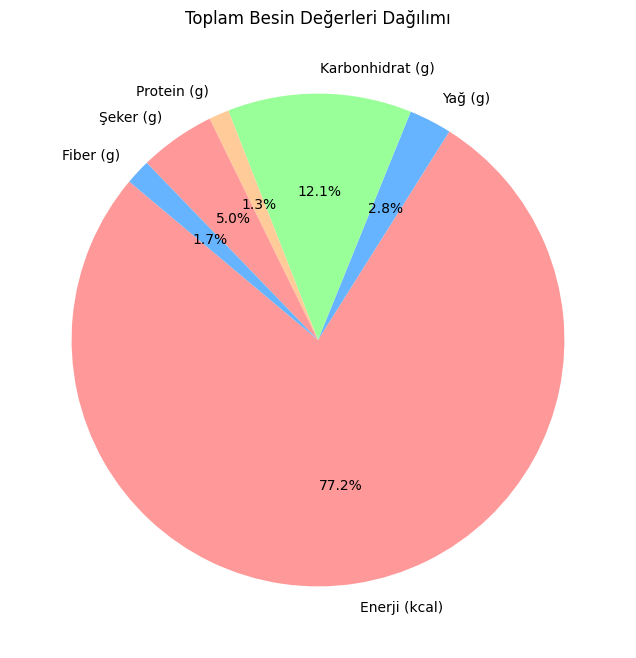

In [24]:
# Ölçü birimlerinin açıklamasını yazıyoruz
olcu_birimi_aciklama = """
Lütfen Tarif Yazarken Bu Birimleri Kullanınız:
gram, gr, kg, kilo, litre, ml, yemek kaşığı, tatlı kaşığı, çay kaşığı, su bardağı, çay bardağı, dilim, adet, tane
"""
olcu_birimi_label = widgets.Label(value=olcu_birimi_aciklama)  # Etiket widget'ı oluşturuyoruz

# Tarif metni için bir metin alanı widget'ı oluşturuyoruz
tarif_metni_widget = widgets.Textarea(
    value='',  # Başlangıçta boş bir değer
    placeholder='Tarif metnini buraya yazın',  # Kullanıcıya yardımcı metin
    description='Tarif Metni:',  # Metin alanının başlığı
    disabled=False  # Kullanıcı metni yazabilsin
)

porsiyon_widget = widgets.BoundedIntText(
    value=1,
    min=1,
    max=100,
    step=1,
    description='Porsiyon:',
    disabled=False
)

# Bir buton widget'ı oluşturuyoruz
buton_widget = widgets.Button(description="Hesapla")  # Butonun başlığı "Hesapla"

# Butona tıklama fonksiyonu
def on_button_click(b):
    # Önceki çıktı ve grafikleri temizliyoruz
    clear_output(wait=True)

    # Kullanıcı tarafından girilen tarif metnini alıyoruz
    tarif_metni = tarif_metni_widget.value
    porsiyon = porsiyon_widget.value

    # Tarif metninden malzemeleri ve miktarları ayıklıyoruz
    malzeme_df = malzeme_ve_miktar_bul(tarif_metni)

    # Eğer malzemeler boşsa (yani doğru ölçü birimi bulunmadıysa), kullanıcıya uyarı veriyoruz
    if malzeme_df.empty:
        print("Yanlış Ölçü Birimi Girdiniz ya da Malzeme Bulunamadı. Lütfen Tekrar Deneyiniz.")
        return

    # Ekrana ayıklanan malzemeleri tablo olarak (Dataframe) gösteriyoruz
    display(widgets.HTML("<h3>Algılanan Malzemeler ve Hesaplanmış Gramajlar</h3>"))
    display(malzeme_df)

    # Ayıklanan malzemelerle toplam besin değerlerini hesaplıyoruz
    toplam_besin_degerleri, bulunamayanlar = besin_degerleri_hesapla(malzeme_df, df)

    if bulunamayanlar:
        display(widgets.HTML("<h3 style='color:red;'>Bulunamayan Malzemeler:</h3>"))
        for item in bulunamayanlar:
            sug = ", ".join(item['suggestions']) if item['suggestions'] else "Öneri bulunamadı"
            print(f" - '{item['query']}' eşleşmedi. Şunu mu demek istediniz? : {sug}")

    print(f"\n--- TOPLAM BESİN DEĞERLERİ ({porsiyon} Porsiyon) ---")
    for besin, deger in toplam_besin_degerleri.items():
        print(f"{besin}: {deger:.2f}")

    if porsiyon > 1:
        print(f"\n--- 1 PORSİYON İÇİN BESİN DEĞERLERİ ---")
        for besin, deger in toplam_besin_degerleri.items():
            print(f"{besin}: {(deger / porsiyon):.2f}")

    # Besin değerlerini görselleştiriyoruz
    besin_degerlerini_gorsellestir(toplam_besin_degerleri)

# Buton ile on_button_click işlevini ilişkilendiriyoruz
buton_widget.on_click(on_button_click)

# Bileşenleri (metin alanı ve buton) ekrana yazdırıyoruz
display(olcu_birimi_label)
display(tarif_metni_widget)
display(porsiyon_widget)
display(buton_widget)
